<a href="https://colab.research.google.com/github/aryac-2006/Machine-Learning-Model/blob/main/Task_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test.txt to test.txt


In [ ]:
import pandas as pd

df = pd.read_csv(
    "test.txt",
    sep=";",
    names=["Text", "Emotions"]
)

print("<<<<<------------------ First 10 rows ------------------>>>>>\n")
print(df.head(10))

print("\n<<<<< Shape of dataset >>>>>\n")
print(df.shape)

print("\n<<<<< Missing values >>>>>>\n")
print(df.isnull().sum())

<<<<<------------------ First 10 rows ------------------>>>>>

                                                Text Emotions
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate from me because i do...  sadness
3  i left with my bouquet of red and yellow tulip...      joy
4    i was feeling a little vain when i did this one  sadness
5  i cant walk into a shop anywhere where i do no...     fear
6   i felt anger when at the end of a telephone call    anger
7  i explain why i clung to a relationship with a...      joy
8  i like to have the same breathless feeling as ...      joy
9  i jest i feel grumpy tired and pre menstrual w...    anger

<<<<< Shape of dataset >>>>>

(2000, 2)

<<<<< Missing values >>>>>>

Text        0
Emotions    0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Unique emotions
print("<<<---------- Unique emotions ---------->>>\n")
print(df["Emotions"].unique())

# Label Encoding
encoder = LabelEncoder()
df["encoded_emotions"] = encoder.fit_transform(df["Emotions"])

# Mapping
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print("\n<<<<-------------------- Label Mapping ---------------------->>>>\n")
print(label_mapping)

print("\n<<<<<---------------- Updated DataFrame ----------------->>>>>\n")
print(df.head())

<<<---------- Unique emotions ---------->>>

['sadness' 'joy' 'fear' 'anger' 'love' 'surprise']

<<<<-------------------- Label Mapping ---------------------->>>>

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

<<<<<---------------- Updated DataFrame ----------------->>>>>

                                                Text Emotions  \
0  im feeling rather rotten so im not very ambiti...  sadness   
1          im updating my blog because i feel shitty  sadness   
2  i never make her separate from me because i do...  sadness   
3  i left with my bouquet of red and yellow tulip...      joy   
4    i was feeling a little vain when i did this one  sadness   

   encoded_emotions  
0                 4  
1                 4  
2                 4  
3                 2  
4                 4  


In [ ]:
# Show before lowercasing
print("<<<<<<============ Before Lowercasing ==============>>>>>>\n")
print(df["Text"].head(5))

# Convert to lowercase
df["Text"] = df["Text"].str.lower()

print("\n<<<<<<============== After Lowercasing ==============>>>>>>\n")
print(df["Text"].head(5))

<<<<<<============ Before Lowercasing ==============>>>>>>

0    im feeling rather rotten so im not very ambiti...
1            im updating my blog because i feel shitty
2    i never make her separate from me because i do...
3    i left with my bouquet of red and yellow tulip...
4      i was feeling a little vain when i did this one
Name: Text, dtype: object

<<<<<<============== After Lowercasing ==============>>>>>>

0    im feeling rather rotten so im not very ambiti...
1            im updating my blog because i feel shitty
2    i never make her separate from me because i do...
3    i left with my bouquet of red and yellow tulip...
4      i was feeling a little vain when i did this one
Name: Text, dtype: object


In [ ]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

before_punctuation = df["Text"].copy()

df["Text"] = df["Text"].apply(remove_punctuation)

print("<<<<<< ::::::: Before and After Punctuation Removal :::::::: >>>>>>\n")
for i in range(5):
    print("-> Before:", before_punctuation.iloc[i])
    print("-> After :", df["Text"].iloc[i])
    print()

<<<<<< ::::::: Before and After Punctuation Removal :::::::: >>>>>>

-> Before: im feeling rather rotten so im not very ambitious right now
-> After : im feeling rather rotten so im not very ambitious right now

-> Before: im updating my blog because i feel shitty
-> After : im updating my blog because i feel shitty

-> Before: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
-> After : i never make her separate from me because i don t ever want her to feel like i m ashamed with her

-> Before: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
-> After : i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived

-> Before: i was feeling a little vain when i did this one
-> After : i was feeling a little vain when i did this one



In [41]:
import re

def remove_numbers(text):
    return re.sub(r"\d+", "", text)

before_numbers = df["text"].copy()

df["text"] = df["text"].apply(remove_numbers)

print("<<<<<< ::::::: Before and After Number Removal :::::::: >>>>>>\n")
for i in range(5):
    print("-> Before:", before_numbers.iloc[i])
    print("-> After :", df["text"].iloc[i])
    print()

<<<<<< ::::::: Before and After Number Removal :::::::: >>>>>>

-> Before: i didnt feel humiliated
-> After : i didnt feel humiliated

-> Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
-> After : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

-> Before: im grabbing a minute to post i feel greedy wrong
-> After : im grabbing a minute to post i feel greedy wrong

-> Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
-> After : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

-> Before: i am feeling grouchy
-> After : i am feeling grouchy



In [26]:
def remove_special_characters(Text):
    return Text.encode("ascii", "ignore").decode("ascii")

df["Text"] = df["Text"].apply(remove_special_characters)

print("<<<<<<<<----------- Cleaned Text ----------->>>>>>>\n")
print(df["Text"].head(10))

<<<<<<<<----------- Cleaned Text ----------->>>>>>>

0    im feeling rather rotten so im not very ambiti...
1            im updating my blog because i feel shitty
2    i never make her separate from me because i do...
3    i left with my bouquet of red and yellow tulip...
4      i was feeling a little vain when i did this one
5    i cant walk into a shop anywhere where i do no...
6     i felt anger when at the end of a telephone call
7    i explain why i clung to a relationship with a...
8    i like to have the same breathless feeling as ...
9    i jest i feel grumpy tired and pre menstrual w...
Name: Text, dtype: object


In [29]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Text"] = df["Text"].apply(remove_stopwords)

print("<<<<<<< ----------------- After Stopword Removal ---------------- >>>>>>>\n")
print(df["Text"].head(5))

<<<<<<< ----------------- After Stopword Removal ---------------- >>>>>>>

0          im feeling rather rotten im ambitious right
1                         im updating blog feel shitty
2      never make separate ever want feel like ashamed
3    left bouquet red yellow tulips arm feeling sli...
4                              feeling little vain one
Name: Text, dtype: object


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"]
)

import re
import string

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove emojis and special characters
    text = text.encode("ascii", "ignore").decode("ascii")

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

print("<<<<<<< ------------ Uncleaned Text and Cleaned Text ------------- >>>>>>>\n")

# Apply pipeline to original text
df["cleaned_text"] = df["text"].apply(clean_text)

print(df[["text", "cleaned_text"]].head(10))

Saving train.txt to train (3).txt
<<<<<<< ------------ Uncleaned Text and Cleaned Text ------------- >>>>>>>

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr... 

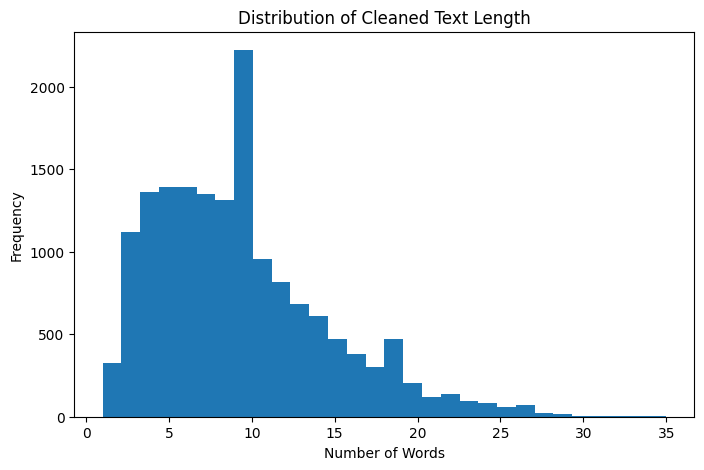


Average text length: 9.3530625

Minimum text length: 1

Maximum text length: 35


In [38]:
import matplotlib.pyplot as plt

# Count words
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=30)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Cleaned Text Length")
plt.show()

# Statistics
print("\nAverage text length:", df["text_length"].mean())
print("\nMinimum text length:", df["text_length"].min())
print("\nMaximum text length:", df["text_length"].max())

In [40]:
import pandas as pd
import re
import string
import nltk

from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords

# Download resources
nltk.download("punkt")
nltk.download("stopwords")

# 1. Load dataset
df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"]
)

# 2. Encode emotion labels
encoder = LabelEncoder()
df["encoded_emotions"] = encoder.fit_transform(df["emotions"])

# 3. Stopwords
stop_words = set(stopwords.words("english"))

# Complete cleaning function
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove emojis and special characters
    text = text.encode(
        "ascii", "ignore"
    ).decode("ascii")

    # Remove stopwords
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# Apply cleaning
df["cleaned_text"] = df["text"].apply(clean_text)

# 4. Save cleaned dataset
df.to_csv(
    "cleaned_emotions.csv",
    index=False
)

# 5. Value counts
print("\n<<<<<< -------------- Emotion Value Counts --------------- >>>>>>\n")
print(df["emotions"].value_counts())

print("\n<<<<<<< -------------------- Label Mapping ------------------ >>>>>>>\n")
print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))

print("\n<<<<<<< --------------------- First 10 rows -------------------- >>>>>>>\n")
print(df.head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



<<<<<< -------------- Emotion Value Counts --------------- >>>>>>

emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<<<<<<< -------------------- Label Mapping ------------------ >>>>>>>

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

<<<<<<< --------------------- First 10 rows -------------------- >>>>>>>

                                                text  emotions  \
0                            i didnt feel humiliated   sadness   
1  i can go from feeling so hopeless to so damned...   sadness   
2   im grabbing a minute to post i feel greedy wrong     anger   
3  i am ever feeling nostalgic about the fireplac...      love   
4                               i am feeling grouchy     anger   
5  ive been feeling a little burdened lately wasn...   sadness   
6  ive been taking or milligrams or times recomme...